
<h1 align="center"><b> Classification of Gravitational Wave Progenitors by the ”K Nearest Neighbors” method (Machine Learning)</b></h1>

<h2> Load Datasets </h2>

In [3]:
# Explore dataset

import pandas as pd
import numpy as np

simulation = pd.read_table("C:/Users/mar1s/Desktop/CEU/tercer curso/Segundo Semestre/Proyectos I/FBB_First_analysis_no_errors/simulation_new.txt", sep="\s+")
simulation_output = pd.read_table("C:/Users/mar1s/Desktop/CEU/tercer curso/Segundo Semestre/Proyectos I/FBB_First_analysis_no_errors/simulation_output_new.txt", sep="\s+")
mock = pd.read_table("C:/Users/mar1s/Desktop/CEU/tercer curso/Segundo Semestre/Proyectos I/FBB_First_analysis_no_errors/mock_data_new.txt", sep="\s+")

final_data = pd.read_table("C:/Users/mar1s/Desktop/CEU/tercer curso/Segundo Semestre/Proyectos I/FBB_First_analysis_no_errors/GWTC3.txt", sep="\s+")

# print("Simulation data:")
# print(simulation.head())


# print("Simulation output:")
# print(simulation_output.head())


# print("Mock data:")
# print(mock.head())


---

<h2> Exploratory Data Analysis </h2>

The datasets are inspected to verify their structure and quality. Missing values are checked, dataset dimensions and column names are compared, and the class distribution in the simulation dataset is analysed. The range of the features is also examined to determine whether the data has already been normalised.

In [4]:
# Check missing values
print("Check for missing values in each dataset:")
print(f"Simulation:{simulation.isnull().sum()}\n"
      f"Simulation output:{simulation_output.isnull().sum()}\n"
      f"Test: {mock.isnull().sum()}")

print("No missing values found in any datasets.")

Check for missing values in each dataset:
Simulation:dL            0
chirp_mass    0
SNR           0
Progenitor    0
dtype: int64
Simulation output:dL            0
chirp_mass    0
SNR           0
Progenitor    0
dtype: int64
Test: dL            0
chirp_mass    0
SNR           0
Progenitor    0
dtype: int64
No missing values found in any datasets.


In [5]:
# Shape and column comparision between simulation files
print(f"simulation shape:        {simulation.shape}")
print(f"simulation_output shape: {simulation_output.shape}")

print(f"\nColumns in simulation:        {simulation.columns.tolist()}")
print(f"Columns in simulation_output: {simulation_output.columns.tolist()}")

# Check if both files are identical
print(f"\n simulation and simulation_output are identical: {simulation.equals(simulation_output)}")

if not simulation.equals(simulation_output):
    print("\nDifferences found:")
    print(simulation.compare(simulation_output))

simulation shape:        (12504, 4)
simulation_output shape: (12504, 4)

Columns in simulation:        ['dL', 'chirp_mass', 'SNR', 'Progenitor']
Columns in simulation_output: ['dL', 'chirp_mass', 'SNR', 'Progenitor']

 simulation and simulation_output are identical: True


As can be seen, both simulation files are identical, so the analysis will continue using the simulation file instead of the simulation_output file.

In [6]:
# Class Counts in the Simulation Dataset
classes_sim, counts_sim = np.unique(simulation['Progenitor'].values, return_counts=True)
dist_sim = dict(zip(classes_sim, counts_sim))
print(f"  {dist_sim}")

  {'ABH-ABH': np.int64(11793), 'ABH-NS': np.int64(607), 'NS-NS': np.int64(104)}


In [7]:
# Data Normalisation Check
stats = simulation.describe()
if not stats.empty:
    print(stats.loc[['min', 'max']])

               dL  chirp_mass          SNR
min     14.635937    1.033577     8.000578
max  17144.546837  137.966243  1197.575689


As can be seen, the data is not normalised, as normalised values should lie between 0 and 1.

---

<h2>Preprocessing</h2>

The three features (dL, chirp_mass, SNR) and the target label (Progenitor) are selected. A StandardScaler is applied after fitting it on the combined training and real data to ensure that both distributions are taken into account. In addition, the string labels are encoded into integers using LabelEncoder.

In [8]:
# Preprocessing
import numpy as np
import pandas as pd

# Define feature columns and target column
col_features = ['dL', 'chirp_mass', 'SNR']
col_target   = 'Progenitor'

# Extract raw features and labels
x_train_raw = simulation[col_features].values.astype(float) # training features
y_train_raw = simulation[col_target].values # training labels

x_test_raw  = mock[col_features].values.astype(float) # test features
y_test_raw  = mock[col_target].values # test labels

x_real = final_data[col_features].values.astype(float) # real GWTC-3 observations

In [9]:
from sklearn.preprocessing import StandardScaler

x_combined = np.vstack([x_train_raw, x_real]) # combine for scaler fitting
x_scaler_new = StandardScaler()
x_scaler_new.fit(x_combined)

# Apply the fitted scaler to all splits
x_train_scaled = x_scaler_new.transform(x_train_raw)
x_test_scaled  = x_scaler_new.transform(x_test_raw)
x_real_scaled  = x_scaler_new.transform(x_real)


print(f"x_train_scaled: {x_train_scaled.shape}")
print(f"x_test_scaled:  {x_test_scaled.shape}")
print(f"x_real_scaled:  {x_real_scaled.shape}")

x_train_scaled: (12504, 3)
x_test_scaled:  (1062, 3)
x_real_scaled:  (85, 3)


In [10]:
# Sanity check: mean ~ 0 and std ~ 1 for training set
print("Train mean (shoub be ~0):", x_train_scaled.mean(axis=0).round(3))
print("Train std  (should be ~1):", x_train_scaled.std(axis=0).round(3))
print("Test  mean:", x_test_scaled.mean(axis=0).round(3))
print("Test  std: ", x_test_scaled.std(axis=0).round(3))

Train mean (shoub be ~0): [0.007 0.006 0.001]
Train std  (should be ~1): [0.999 0.999 1.003]
Test  mean: [-0.82  -0.344 -0.039]
Test  std:  [0.497 0.783 0.465]


After scaling, the training set should have a mean close to 0 and a standard deviation close to 1 for each feature. If this is not the case, it would indicate that the scaling process failed. In this case, the transformation has worked correctly. In this case, train has mean ~ 0 and std ~ 1 because the scaler is fitted on it. Test is only transformed, so it does not need to follow this. This is expected.

In [12]:
from sklearn.preprocessing import LabelEncoder

# Label encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded  = label_encoder.transform(y_test_raw)

print(f"\nDetected classes: {label_encoder.classes_}")
print(f"Train shape: {x_train_scaled.shape}")
print(f"Test  shape: {x_test_scaled.shape}")


Detected classes: ['ABH-ABH' 'ABH-NS' 'NS-NS']
Train shape: (12504, 3)
Test  shape: (1062, 3)


El labelenconder para convertir las etiques en valores enteros [0,1,2]

In [13]:
# Count the number of collisions of each type in the test set
classes, counts = np.unique(y_test_encoded, return_counts=True)

distribution = dict(zip(classes, counts))
print("Class Distribution in the Training Set:")
for cls, quantity in distribution.items():
    print(f"Class {cls} ({label_encoder.classes_[cls]}): {quantity} samples")

print(f"Total training samples: {len(y_test_encoded)}")

Class Distribution in the Training Set:
Class 0 (ABH-ABH): 1012 samples
Class 1 (ABH-NS): 46 samples
Class 2 (NS-NS): 4 samples
Total training samples: 1062


In [14]:
# Checking Class Balance and Imbalance

count_series = pd.Series(y_train_encoded).value_counts().sort_index()
for i, cls_name in enumerate(label_encoder.classes_):
    print(f"{cls_name}: {count_series[i]} eventos")

ratio = count_series.max() / count_series.min()
print(f"\nMax/Min class ratio:: {ratio:.2f}")
if ratio < 2:
    print("Classes are balanced → scoring='accuracy'")
else:
    print("Classes are imbalanced → scoring='balanced_accuracy'")

ABH-ABH: 11793 eventos
ABH-NS: 607 eventos
NS-NS: 104 eventos

Max/Min class ratio:: 113.39
Classes are imbalanced → scoring='balanced_accuracy'


The dataset is imbalanced, with ABH-ABH being the dominant class. Therefore, balanced accuracy is preferred over standard accuracy, as it gives equal importance to all classes.

---

<h2>Training Model</h2>

The KNN model is trained by comparing each event with similar events in the training set. Different values of K are tested to find the configuration that provides the best classification performance. 

In [16]:

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(metric='euclidean') # we are using euclidean distance

param = {
    'n_neighbors': range(1, 31, 2), # odd values from 1 to 29
    'weights': ['uniform', 'distance'] # neighbour weighting: equal votes | distance-based votes
}

grid_search = GridSearchCV(knn, param, cv=5, scoring='balanced_accuracy')
grid_search.fit(x_train_scaled, y_train_encoded)

best_model = grid_search.best_estimator_ # best knn model
k_value  = grid_search.best_params_['n_neighbors']

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Balanced Accuracy (cross-validation): {grid_search.best_score_:.4f}")

print(f"Optimal K value selected: {k_value}")




Best parameters found: {'n_neighbors': 1, 'weights': 'uniform'}
Balanced Accuracy (cross-validation): 0.9781
Optimal K value selected: 1


To train the model, GridSearchCV is used, which automatically tests different parameter combinations and selects the one that works best.

Cross-validation (cv=5) is applied, which means the training set is split into 5 parts. The model is trained 5 times, each time using one part as validation. This makes the evaluation more reliable and reduces the risk of overfitting.

The parameters tested are:
- $K$: odd values from 1 to 29
- $weights$: uniform (all neighbours count equally) or distance (closer neighbours have more influence)

Balanced accuracy is used as the metric since the classes are imbalanced. The best parameter combination is selected automatically.



__Results obtained:__

The best model uses K=1, which means that each event is classified according to its nearest neighbour in the training set. This result suggests that the classes are well separated and that similar events usually belong to the same category. In addition, the balanced accuracy score (0.978) indicates that the model achieves a very high classification performance.

<h2>Data Visualization</h2>

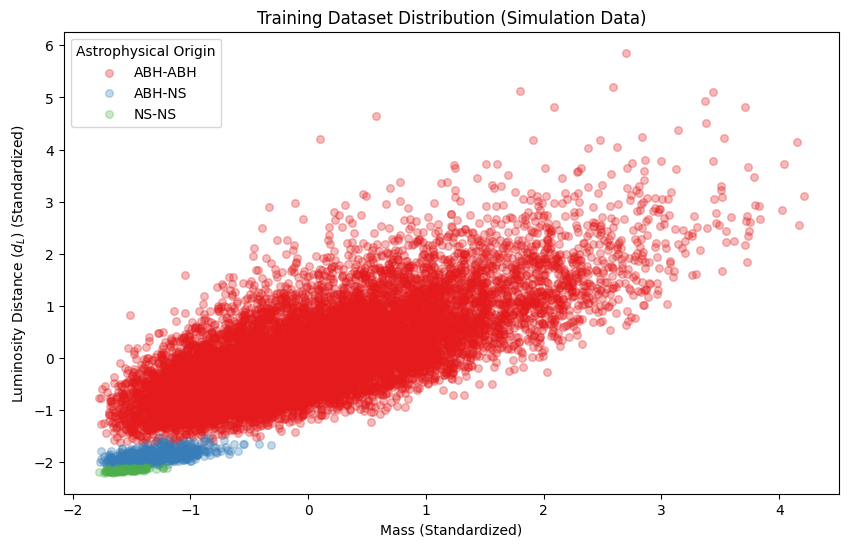

In [21]:
import matplotlib.pyplot as plt

# Red=ABH-ABH, Blue=ABH-NS, Green=NS-NS
colors = ['#e41a1c', '#377eb8', '#4daf4a']
y_pred = best_model.predict(x_test_scaled)
feature_names = ['Mass', 'Luminosity Distance ($d_L$)']


# Graph 1 : Training data distribution
plt.figure(figsize=(10, 6))

for i in range(len(label_encoder.classes_)):
    mask = (y_train_encoded == i)
    plt.scatter(x_train_scaled[mask, 0], x_train_scaled[mask, 1],
                c=colors[i], label=label_encoder.classes_[i], alpha=0.3, s=30)

plt.title("Training Dataset Distribution (Simulation Data)")
plt.xlabel(f'{feature_names[0]} (Standardized)')
plt.ylabel(f'{feature_names[1]} (Standardized)')
plt.legend(title="Astrophysical Origin")
plt.show()

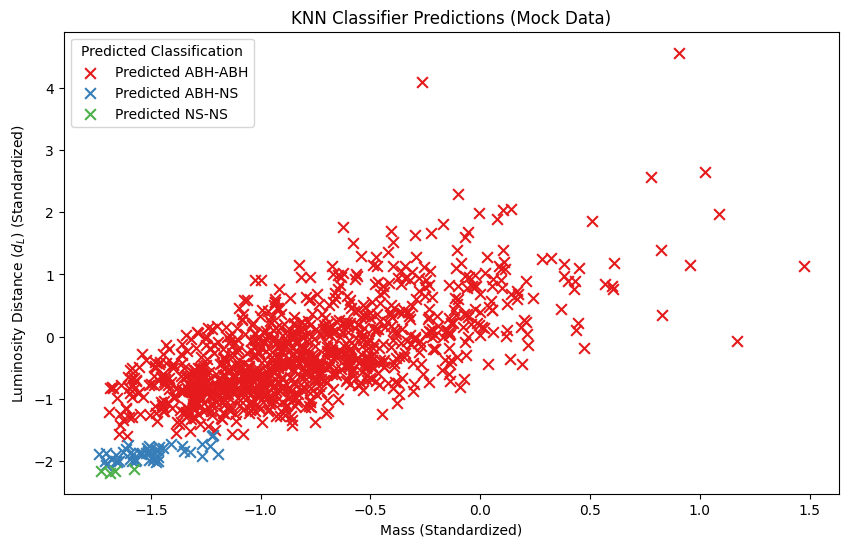

In [20]:
# Graph 2: KNN predictions on mock/test data
plt.figure(figsize=(10, 6))

for i in range(len(label_encoder.classes_)):
    mask = (y_pred == i)
    plt.scatter(x_test_scaled[mask, 0], x_test_scaled[mask, 1],
                c=colors[i], label=f'Predicted {label_encoder.classes_[i]}', marker='x', s=60)

plt.title("KNN Classifier Predictions (Mock Data)")
plt.xlabel(f'{feature_names[0]} (Standardized)')
plt.ylabel(f'{feature_names[1]} (Standardized)')
plt.legend(title="Predicted Classification")
plt.show()

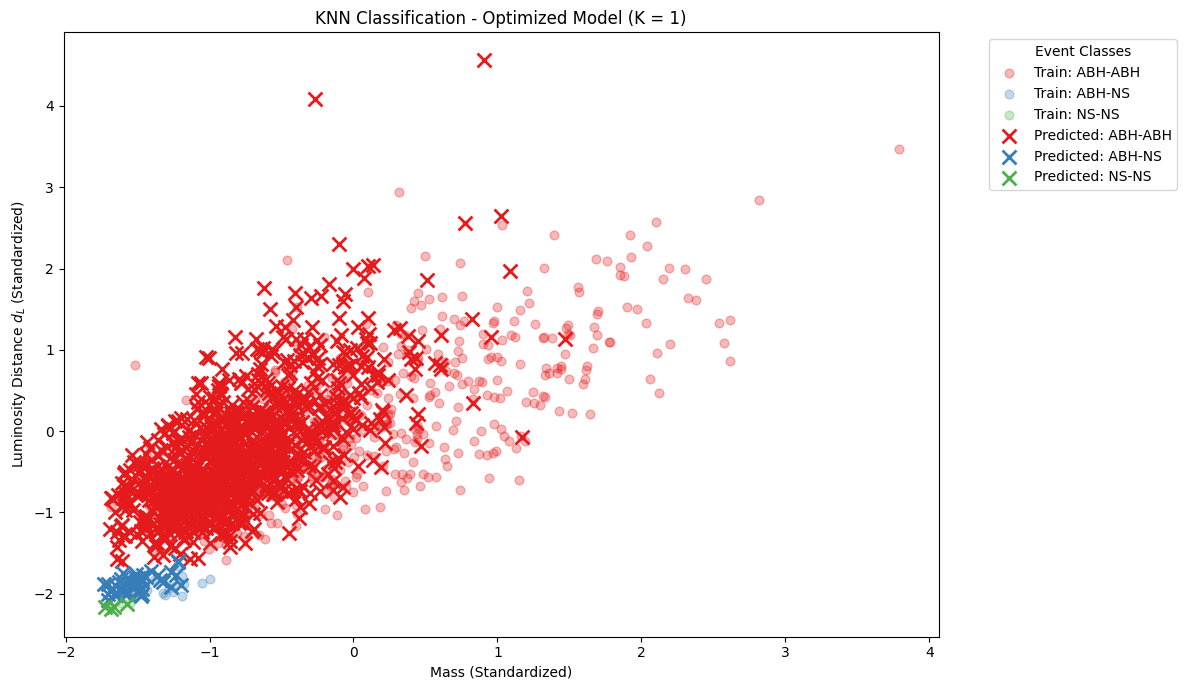

In [22]:
# Graph 3: Combined training + predictions
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.figure(figsize=(12, 7))

# Red=ABH-ABH, Blue=ABH-NS, Green=NS-NS
colors = ['#e41a1c', '#377eb8', '#4daf4a']

# plot 500 random training points to avoid overplotting
n_samples = 500
indices = np.random.choice(len(x_train_scaled), min(len(x_train_scaled), n_samples), replace=False)

# Training points (circles)
for i in range(len(label_encoder.classes_)):
    mask = (y_train_encoded[indices] == i)
    plt.scatter(x_train_scaled[indices][mask, 0],
                x_train_scaled[indices][mask, 1],
                c=colors[i], marker='o',
                label=f'Train: {label_encoder.classes_[i]}',
                alpha=0.3, s=40)

# Predicted test points (crosses)
y_pred = best_model.predict(x_test_scaled)
for i in range(len(label_encoder.classes_)):
    mask = (y_pred == i)
    plt.scatter(x_test_scaled[mask, 0],
                x_test_scaled[mask, 1],
                c=colors[i], marker='x', s=100,
                label=f'Predicted: {label_encoder.classes_[i]}',
                linewidths=2)

# Chart Formatting in English
plt.title(f"KNN Classification - Optimized Model (K = {k_value})")
plt.xlabel('Mass (Standardized)')
plt.ylabel('Luminosity Distance $d_L$ (Standardized)')

# Move legend outside to keep the plot area clean
plt.legend(title="Event Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<h2> Model Evaluation </h2>

Once the model is trained, we evaluate it on the mock test set, which it has never seen before. This tells us how well it generalises to new data.

In [23]:
# Evaluate the model

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate test
y_pred = best_model.predict(x_test_scaled)

print("\n--- Classification Report ---")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))



--- Classification Report ---
              precision    recall  f1-score   support

     ABH-ABH       1.00      1.00      1.00      1012
      ABH-NS       0.96      1.00      0.98        46
       NS-NS       1.00      1.00      1.00         4

    accuracy                           1.00      1062
   macro avg       0.99      1.00      0.99      1062
weighted avg       1.00      1.00      1.00      1062



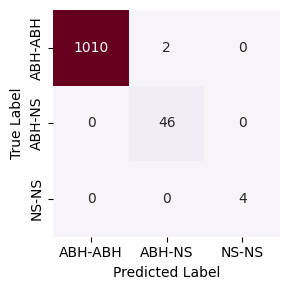

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar = False)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


<h2> Inference on Real Data </h2>

In [28]:
# Apply the trained KNN to real, unlabelled observations
y_real_pred = best_model.predict(x_real_scaled)

# Decode numeric indices back to human-readable class names
names_predicted = label_encoder.inverse_transform(y_real_pred)

print("\nScientific classification of real events:")
print(names_predicted)

# Summary count per collision category
print("\nReal events detected per class:")
unique_classes, class_counts  = np.unique(names_predicted, return_counts=True)
for i, c in zip(unique_classes, class_counts ):
    print(f"{i}: {c} collisions")


Scientific classification of real events:
['ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH'
 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'NS-NS' 'ABH-ABH'
 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH'
 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH'
 'ABH-NS' 'ABH-ABH' 'ABH-ABH' 'ABH-NS' 'ABH-NS' 'ABH-ABH' 'ABH-NS'
 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-NS' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH'
 'ABH-ABH' 'ABH-ABH' 'ABH-NS' 'ABH-NS' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH'
 'ABH-NS' 'ABH-NS' 'ABH-NS' 'ABH-ABH' 'ABH-NS' 'ABH-NS' 'ABH-ABH' 'ABH-NS'
 'ABH-ABH' 'ABH-NS' 'ABH-ABH' 'ABH-NS' 'ABH-NS' 'ABH-ABH' 'ABH-ABH'
 'ABH-ABH' 'NS-NS' 'ABH-ABH' 'ABH-ABH' 'ABH-NS' 'ABH-ABH' 'ABH-ABH'
 'ABH-ABH' 'ABH-NS' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH'
 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-ABH' 'ABH-NS' 'ABH-ABH']

Real events detected per class:
ABH-ABH: 64 collisions
ABH-NS: 19 collisions
NS-NS: 2 collisions


In [30]:
# Create a real final result table
final_results = final_data.copy()

# We add the column with the labels that the KNN predicted
final_results['Clasificacion_Real'] = names_predicted

# print(final_results[['commonName', 'chirp_mass', 'dL', 'SNR', 'Clasificacion_Real']])

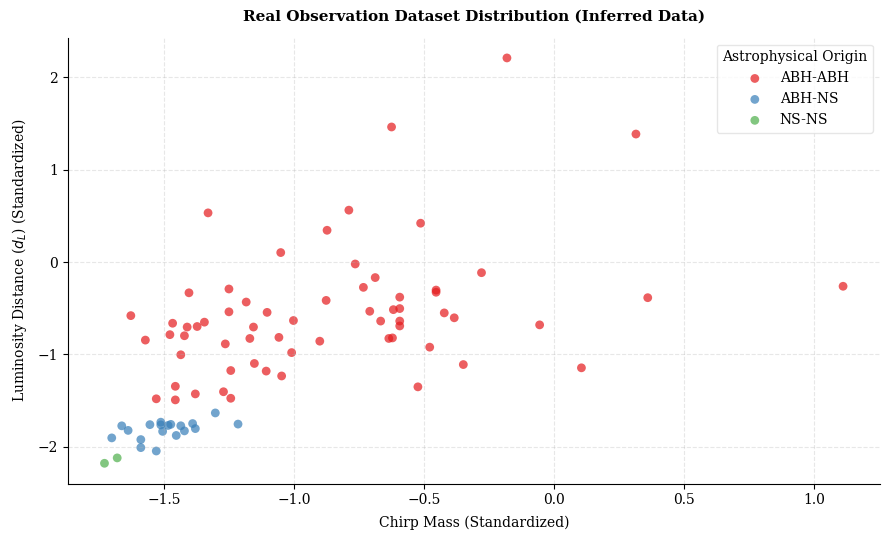

In [31]:
# Final Results Visual Representation

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

colors = ['#e41a1c', '#377eb8', '#4daf4a']
collisions = ['ABH-ABH', 'ABH-NS', 'NS-NS']

feature_names = ['Chirp Mass', 'Luminosity Distance ($d_L$)']

plt.figure(figsize=(9, 5.5))

for i in range(len(collisions)):
    mask = (y_real_pred == i)
    plt.scatter(x_real_scaled[mask, 0], x_real_scaled[mask, 1],
                c=colors[i], label=collisions[i], alpha=0.7, s=40, edgecolors='none')

plt.title("Real Observation Dataset Distribution (Inferred Data)", fontsize=11, pad=12, weight='bold')
plt.xlabel(f'{feature_names[0]} (Standardized)', fontsize=10, labelpad=6)
plt.ylabel(f'{feature_names[1]} (Standardized)', fontsize=10, labelpad=6)

# Legend
plt.legend(title="Astrophysical Origin", loc='upper right', frameon=True, facecolor='white', edgecolor='#e0e0e0')
plt.grid(True, linestyle='--', alpha=0.3)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

